In [1]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd 

df = pd.read_csv("C:/Users/SnehaG/Downloads/archive/synthetic_drug_data.csv")

print(df.head())

       ReportID  PatientAge  Gender      DrugName Dosage  DurationDays  \
0  REP-VJpHH7RG          52   Other     Ibuprofen  658mg            31   
1  REP-xZHEIV6F          64    Male  Atorvastatin  359mg            33   
2  REP-j2PXcrTb          45  Female   Amoxicillin  179mg            28   
3  REP-vzYm2NEH          72  Female    Prednisone   46mg            29   
4  REP-WWcINmT6          56    Male  Atorvastatin  936mg            28   

                      ConcomitantDrugs  ADR_Code Seriousness  OnsetDays  
0  Simvastatin, Fluoxetine, Gabapentin  10016256        mild         12  
1                                  NaN  10019211        mild          5  
2                                  NaN  10016256        mild          3  
3                Metformin, Lisinopril  10013968        mild          6  
4                                  NaN  10037660        mild          9  


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   ReportID          1000000 non-null  str  
 1   PatientAge        1000000 non-null  int64
 2   Gender            1000000 non-null  str  
 3   DrugName          1000000 non-null  str  
 4   Dosage            1000000 non-null  str  
 5   DurationDays      1000000 non-null  int64
 6   ConcomitantDrugs  562172 non-null   str  
 7   ADR_Code          1000000 non-null  int64
 8   Seriousness       1000000 non-null  str  
 9   OnsetDays         1000000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 76.3 MB
None


In [4]:
print(df.isnull().sum())

ReportID                 0
PatientAge               0
Gender                   0
DrugName                 0
Dosage                   0
DurationDays             0
ConcomitantDrugs    437828
ADR_Code                 0
Seriousness              0
OnsetDays                0
dtype: int64


In [5]:
# Cleaning Dataset

In [6]:
# remove duplicates
df.drop_duplicates(inplace=True)

In [7]:
# fill missing concomitant drugs
df['ConcomitantDrugs'] = df['ConcomitantDrugs'].fillna('None Reported')

In [8]:
# standardize gender
df['Gender'] = df['Gender'].str.capitalize()

In [9]:
# standardize seriousness  
df['Seriousness'] = df['Seriousness'].str.capitalize()

In [10]:
# Exploratory Data Analysis (EDA)

In [11]:
# Basic Dataset Overview
print(df.shape)          # Shape of dataset
print(df.columns)        # Column names
print(df.dtypes)         # Data types
print(df.describe())     # Statistical summary

(1000000, 10)
Index(['ReportID', 'PatientAge', 'Gender', 'DrugName', 'Dosage',
       'DurationDays', 'ConcomitantDrugs', 'ADR_Code', 'Seriousness',
       'OnsetDays'],
      dtype='str')
ReportID              str
PatientAge          int64
Gender                str
DrugName              str
Dosage                str
DurationDays        int64
ConcomitantDrugs      str
ADR_Code            int64
Seriousness           str
OnsetDays           int64
dtype: object
           PatientAge    DurationDays      ADR_Code       OnsetDays
count  1000000.000000  1000000.000000  1.000000e+06  1000000.000000
mean        49.603926       29.997227  1.002093e+07        7.350763
std         14.729829        5.476767  1.392893e+04        3.111634
min         18.000000        7.000000  1.000008e+07        0.000000
25%         39.000000       26.000000  1.001274e+07        5.000000
50%         50.000000       30.000000  1.001626e+07        7.000000
75%         60.000000       34.000000  1.003766e+07        9.

In [12]:
# Check Unique Values
print(df['Gender'].unique())        # Gender categories
print(df['Seriousness'].unique())   # Seriousness categories

<StringArray>
['Other', 'Male', 'Female']
Length: 3, dtype: str
<StringArray>
['Mild', 'Severe', 'Moderate', 'Fatal']
Length: 4, dtype: str


DrugName
Metformin        50401
Simvastatin      50378
Prednisone       50348
Losartan         50321
Levothyroxine    50240
Amoxicillin      50121
Aspirin          50060
Lisinopril       50024
Gabapentin       50015
Ibuprofen        49929
Name: count, dtype: int64


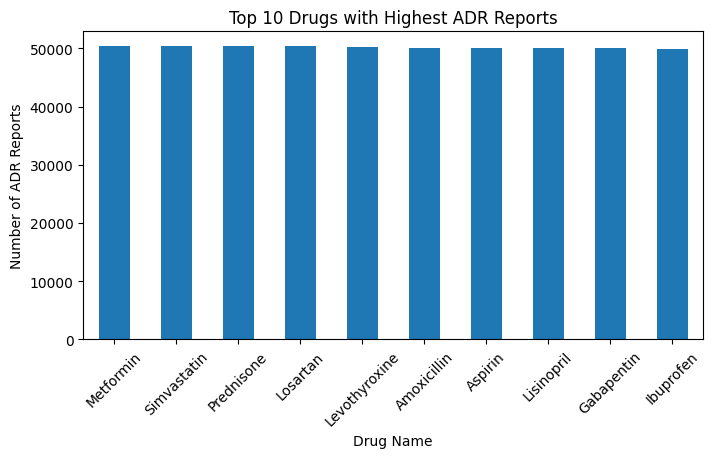

In [13]:
# Top Reported Drugs
top_drugs = df['DrugName'].value_counts().head(10)
print(top_drugs)

# Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
top_drugs.plot(kind='bar')

plt.xlabel("Drug Name")
plt.ylabel("Number of ADR Reports")
plt.title("Top 10 Drugs with Highest ADR Reports")

plt.xticks(rotation=45)
plt.show()

Seriousness
Mild        800261
Moderate    149718
Severe       39946
Fatal        10075
Name: count, dtype: int64


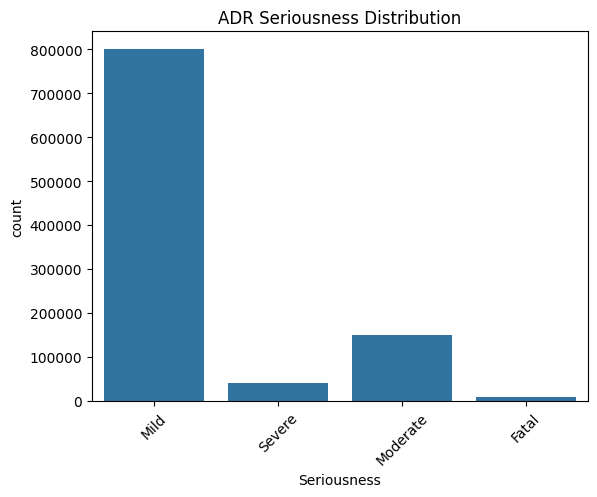

In [14]:
# Serious vs Non-Serious ADRs
print(df['Seriousness'].value_counts())

# Visualization
import seaborn as sns
sns.countplot(x='Seriousness', data=df)

plt.title("ADR Seriousness Distribution")
plt.xticks(rotation=45)

plt.show()

Gender
Female    480166
Male      479444
Other      40390
Name: count, dtype: int64


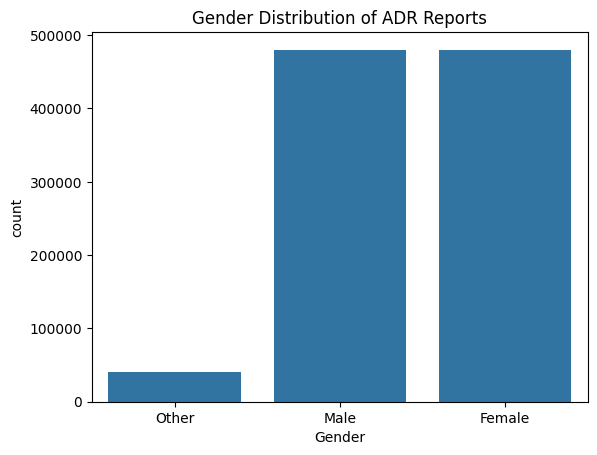

In [15]:
# Gender Analysis 
print(df['Gender'].value_counts())

# Visualization
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution of ADR Reports")

plt.show()

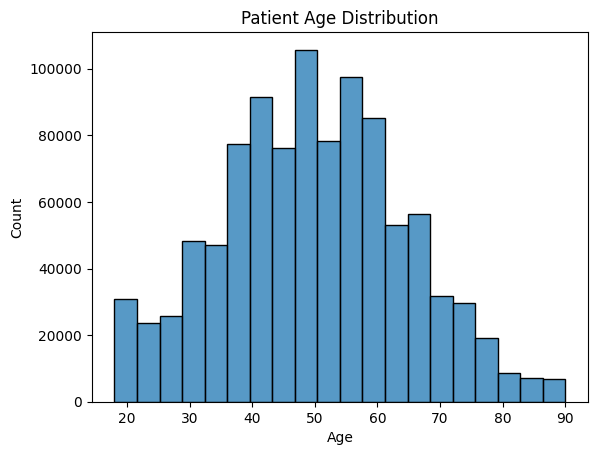

In [16]:
# Age Distribution
sns.histplot(df['PatientAge'], bins=20)

plt.title("Patient Age Distribution")
plt.xlabel("Age")

plt.show()

7.350763


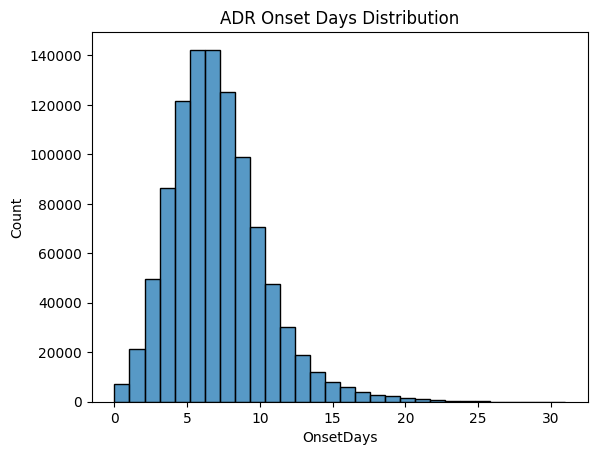

In [17]:
# Onset Days Analysis
print(df['OnsetDays'].mean())

# Visualization 
sns.histplot(df['OnsetDays'], bins=30)

plt.title("ADR Onset Days Distribution")

plt.show()

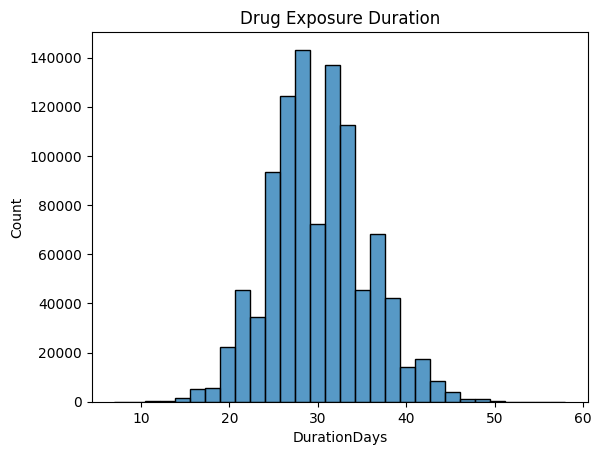

In [18]:
# DurationDays Analysis
sns.histplot(df['DurationDays'], bins=30)

plt.title("Drug Exposure Duration")

plt.show()

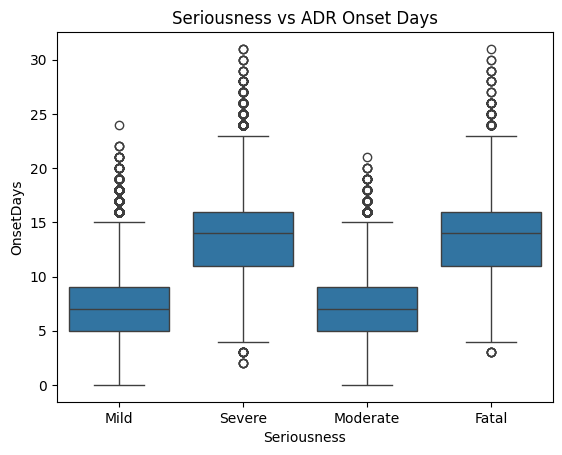

In [19]:
# Relationship Analysis (Seriousness vs OnsetDays)
sns.boxplot(x='Seriousness', y='OnsetDays', data=df)

plt.title("Seriousness vs ADR Onset Days")

plt.show()

In [20]:
# Concomitant Drugs Analysis (Most common concomitant drugs)
print(df['ConcomitantDrugs'].value_counts().head(10))

ConcomitantDrugs
None Reported          437828
Levothyroxine            9598
Hydrochlorothiazide      9560
Lisinopril               9537
Prednisone               9507
Omeprazole               9467
Metformin                9466
Sertraline               9458
Fluoxetine               9445
Amoxicillin              9442
Name: count, dtype: int64


              PatientAge  DurationDays  OnsetDays
PatientAge      1.000000      0.000220  -0.000587
DurationDays    0.000220      1.000000   0.000848
OnsetDays      -0.000587      0.000848   1.000000


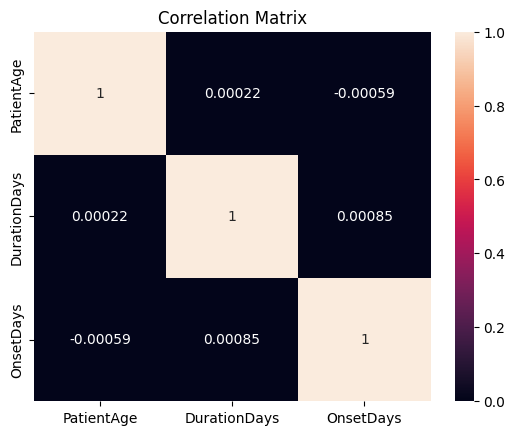

In [21]:
# Correlation Analysis
numeric_df = df[['PatientAge', 'DurationDays', 'OnsetDays']]
print(numeric_df.corr())

# Visualization
sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Matrix")

plt.show()

In [22]:
df.to_csv("cleaned_adr_data.csv", index=False)

In [23]:
!pip install sqlalchemy pymysql


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pymysql
from sqlalchemy import create_engine

# MySQL connection
# Replace placeholders with your actual details
username = "root"  
password = "admin123"  
host = "localhost" 
port = "3306" 
database = "adr_analysis"  

# Create the connection engine
engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}/{database}")

# Export your DataFrame to MySQL
table_name = "adr_data"         # Choose any table name
df.to_sql(table_name, engine, if_exists ="replace", index=False)


print("Data successfully loaded into MySQL!")

In [26]:
# Read back sample
pd.read_sql("SELECT * FROM adr_data LIMIT 5;",engine)

,ReportID,PatientAge,Gender,DrugName,Dosage,DurationDays,ConcomitantDrugs,ADR_Code,Seriousness,OnsetDays
0,REP-VJpHH7RG,52,Other,Ibuprofen,658mg,31,"Simvastatin, Fluoxetine, Gabapentin",10016256,Mild,12
1,REP-xZHEIV6F,64,Male,Atorvastatin,359mg,33,None Reported,10019211,Mild,5
2,REP-j2PXcrTb,45,Female,Amoxicillin,179mg,28,None Reported,10016256,Mild,3
3,REP-vzYm2NEH,72,Female,Prednisone,46mg,29,"Metformin, Lisinopril",10013968,Mild,6
4,REP-WWcINmT6,56,Male,Atorvastatin,936mg,28,None Reported,10037660,Mild,9
